In [1]:
"""
BatchNorm: Effect of Scale (γ) and Shift (β) parameters
=========================================================
Two-layer network on dummy binary classification.
Left panel  → BN without γ,β  (normalize only)
Right panel → BN with learned γ,β
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


In [2]:

torch.manual_seed(42)

# ── 1. Dummy data ──────────────────────────────────────────────────────────────
# Two Gaussians: class 0 centered at (-3,-3), class 1 at (+3,+3)
N = 500
X0 = torch.randn(N, 2) + torch.tensor([-3.0, -3.0])
X1 = torch.randn(N, 2) + torch.tensor([ 3.0,  3.0])
X  = torch.cat([X0, X1], dim=0)
y  = torch.cat([torch.zeros(N), torch.ones(N)]).long()

# shuffle
perm = torch.randperm(2 * N)
X, y = X[perm], y[perm]


In [3]:

# ── 2. Models ──────────────────────────────────────────────────────────────────
class NetNormOnly(nn.Module):
    """BN with affine=False  →  only normalizes, no γ/β"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.bn1 = nn.BatchNorm1d(64, affine=False)   # ← no scale/shift
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32, affine=False)
        self.fc3 = nn.Linear(32, 2)
        self.act = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.bn1(self.fc1(x)))
        x = self.act(self.bn2(self.fc2(x)))
        return self.fc3(x)


class NetWithAffine(nn.Module):
    """BN with affine=True  →  normalizes + learns γ/β"""
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 64)
        self.bn1 = nn.BatchNorm1d(64, affine=True)    # ← learns γ,β
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32, affine=True)
        self.fc3 = nn.Linear(32, 2)
        self.act = nn.Sigmoid()

    def forward(self, x):
        x = self.act(self.bn1(self.fc1(x)))
        x = self.act(self.bn2(self.fc2(x)))
        return self.fc3(x)



In [4]:
# ── 3. Training loop ───────────────────────────────────────────────────────────
def train(model, epochs=200, lr=0.01):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    losses, accs = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X).argmax(dim=1)
            acc   = (preds == y).float().mean().item()

        losses.append(loss.item())
        accs.append(acc * 100)

    return losses, accs


print("Training model WITHOUT γ,β ...")
model_no_affine = NetNormOnly()
loss_no, acc_no = train(model_no_affine)

print("Training model WITH    γ,β ...")
model_affine = NetWithAffine()
loss_af, acc_af = train(model_affine)


Training model WITHOUT γ,β ...
Training model WITH    γ,β ...


In [5]:

# ── 4. Capture internal activation distributions ──────────────────────────────
def get_activations(model, layer_name):
    """Hook to capture post-BN activations (before sigmoid)."""
    acts = {}
    def hook(module, input, output):
        acts['out'] = output.detach()

    if layer_name == 'bn1':
        handle = model.bn1.register_forward_hook(hook)
    else:
        handle = model.bn2.register_forward_hook(hook)

    model.eval()
    with torch.no_grad():
        model(X)
    handle.remove()
    return acts['out'].numpy().flatten()


acts_no_bn1 = get_activations(model_no_affine, 'bn1')
acts_af_bn1 = get_activations(model_affine,    'bn1')

# learned γ,β values from first BN layer
gamma_vals = model_affine.bn1.weight.detach().numpy()
beta_vals  = model_affine.bn1.bias.detach().numpy()


  Final Loss  | Norm only: 0.0194  |  With γ,β: 0.0172
  Final Acc   | Norm only: 100.0%  |  With γ,β: 100.0%
  γ range     | min=0.987  max=1.013  mean=1.001
  β range     | min=-0.000  max=0.000  mean=0.000
  → If γ,β were useless, γ≈1 and β≈0 everywhere.
  → Spread away from 1/0 shows the network actively used them.

Plot saved → batchnorm_scale_shift.png


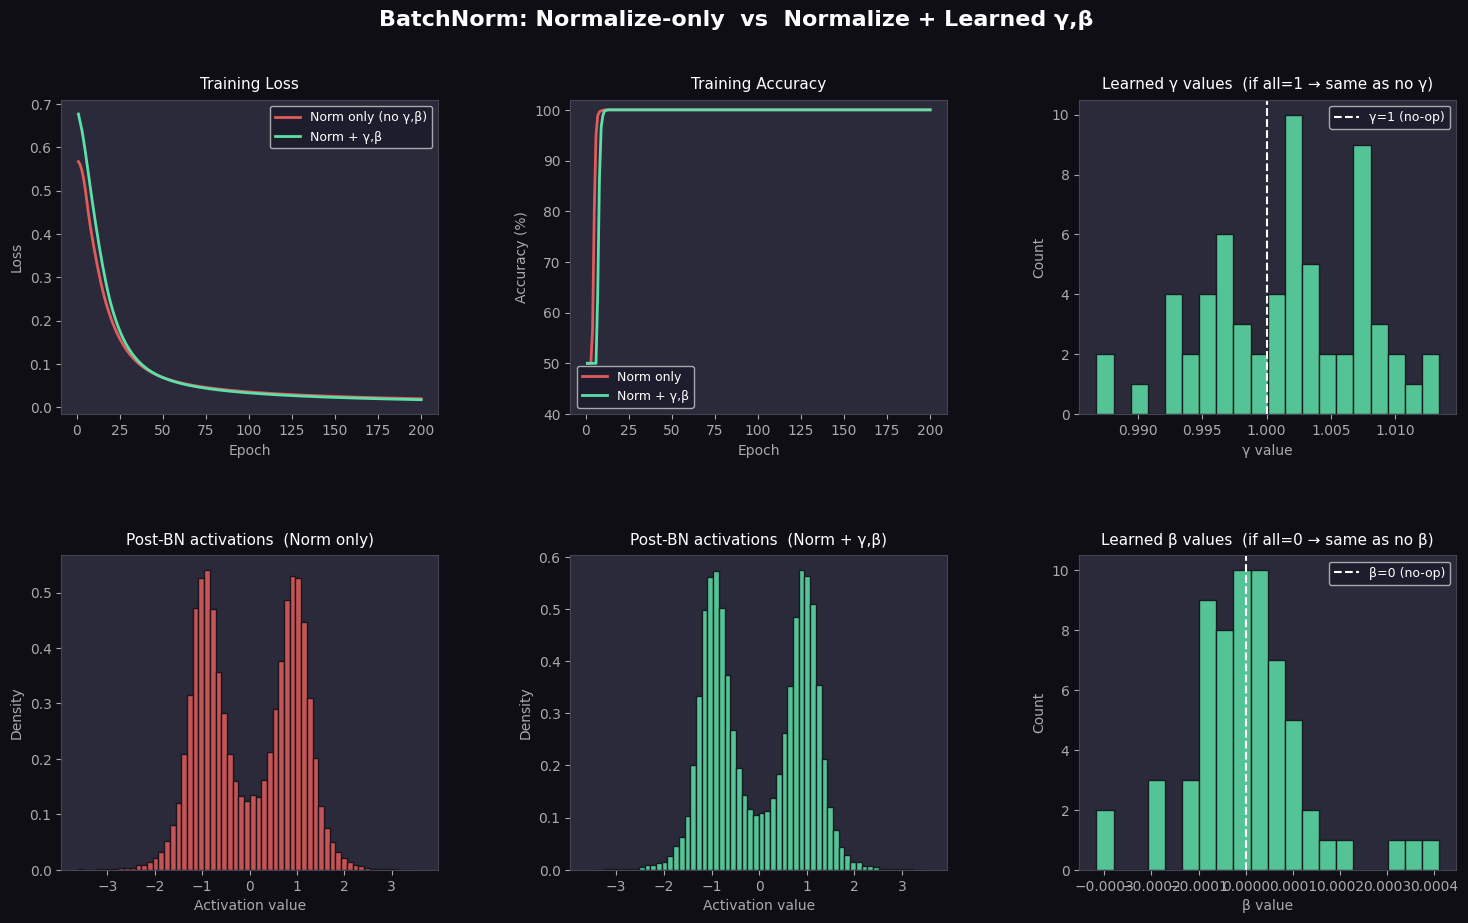

In [7]:


# ── 5. Plot ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10), facecolor='#0e0e14')
fig.suptitle('BatchNorm: Normalize-only  vs  Normalize + Learned γ,β',
             fontsize=16, color='white', fontweight='bold', y=0.97)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

C_NO  = '#e05c5c'   # red   → no affine
C_AF  = '#5ce0a8'   # green → with affine
C_AX  = '#2a2a3a'   # axis bg

def style_ax(ax, title):
    ax.set_facecolor(C_AX)
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.tick_params(colors='#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444455')
    ax.yaxis.label.set_color('#aaaaaa')
    ax.xaxis.label.set_color('#aaaaaa')

epochs = range(1, 201)

# ── Row 0: Loss curves ─────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, loss_no, color=C_NO, lw=2, label='Norm only (no γ,β)')
ax1.plot(epochs, loss_af, color=C_AF, lw=2, label='Norm + γ,β')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style_ax(ax1, 'Training Loss')

# ── Row 0: Accuracy curves ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, acc_no, color=C_NO, lw=2, label='Norm only')
ax2.plot(epochs, acc_af, color=C_AF, lw=2, label='Norm + γ,β')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_ylim([40, 102])
ax2.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style_ax(ax2, 'Training Accuracy')

# ── Row 0: γ distribution ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(gamma_vals, bins=20, color=C_AF, alpha=0.85, edgecolor='#0e0e14')
ax3.axvline(1.0, color='white', lw=1.5, linestyle='--', label='γ=1 (no-op)')
ax3.set_xlabel('γ value'); ax3.set_ylabel('Count')
ax3.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style_ax(ax3, 'Learned γ values  (if all=1 → same as no γ)')

# ── Row 1: Post-BN activation distributions ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(acts_no_bn1, bins=60, color=C_NO, alpha=0.85, edgecolor='#0e0e14', density=True)
ax4.set_xlabel('Activation value'); ax4.set_ylabel('Density')
style_ax(ax4, 'Post-BN activations  (Norm only)')

ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(acts_af_bn1, bins=60, color=C_AF, alpha=0.85, edgecolor='#0e0e14', density=True)
ax5.set_xlabel('Activation value'); ax5.set_ylabel('Density')
style_ax(ax5, 'Post-BN activations  (Norm + γ,β)')

# ── Row 1: β distribution ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(beta_vals, bins=20, color=C_AF, alpha=0.85, edgecolor='#0e0e14')
ax6.axvline(0.0, color='white', lw=1.5, linestyle='--', label='β=0 (no-op)')
ax6.set_xlabel('β value'); ax6.set_ylabel('Count')
ax6.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style_ax(ax6, 'Learned β values  (if all=0 → same as no β)')

# ── Final stats printout ───────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  Final Loss  | Norm only: {loss_no[-1]:.4f}  |  With γ,β: {loss_af[-1]:.4f}")
print(f"  Final Acc   | Norm only: {acc_no[-1]:.1f}%  |  With γ,β: {acc_af[-1]:.1f}%")
print(f"  γ range     | min={gamma_vals.min():.3f}  max={gamma_vals.max():.3f}  mean={gamma_vals.mean():.3f}")
print(f"  β range     | min={beta_vals.min():.3f}  max={beta_vals.max():.3f}  mean={beta_vals.mean():.3f}")
print(f"{'='*50}")
print("  → If γ,β were useless, γ≈1 and β≈0 everywhere.")
print("  → Spread away from 1/0 shows the network actively used them.")

# plt.savefig('/mnt/user-data/outputs/batchnorm_scale_shift.png',
#             dpi=150, bbox_inches='tight', facecolor='#0e0e14')
print("\nPlot saved → batchnorm_scale_shift.png")
plt.show()

Training model WITHOUT γ,β ...
Training model WITH    γ,β ...
Computing decision boundaries ...

  Final accuracy  | Norm only : 100.0%
                  | With γ,β  : 100.0%
  Mean confidence | Norm only : 100.0%
                  | With γ,β  : 100.0%
  High conf (>90%)| Norm only : 100.0% of samples
                  | With γ,β  : 100.0% of samples
  → Brighter regions in the last plot = where γ,β
    caused the model to predict differently.

Plot saved → batchnorm_decision_boundary.png


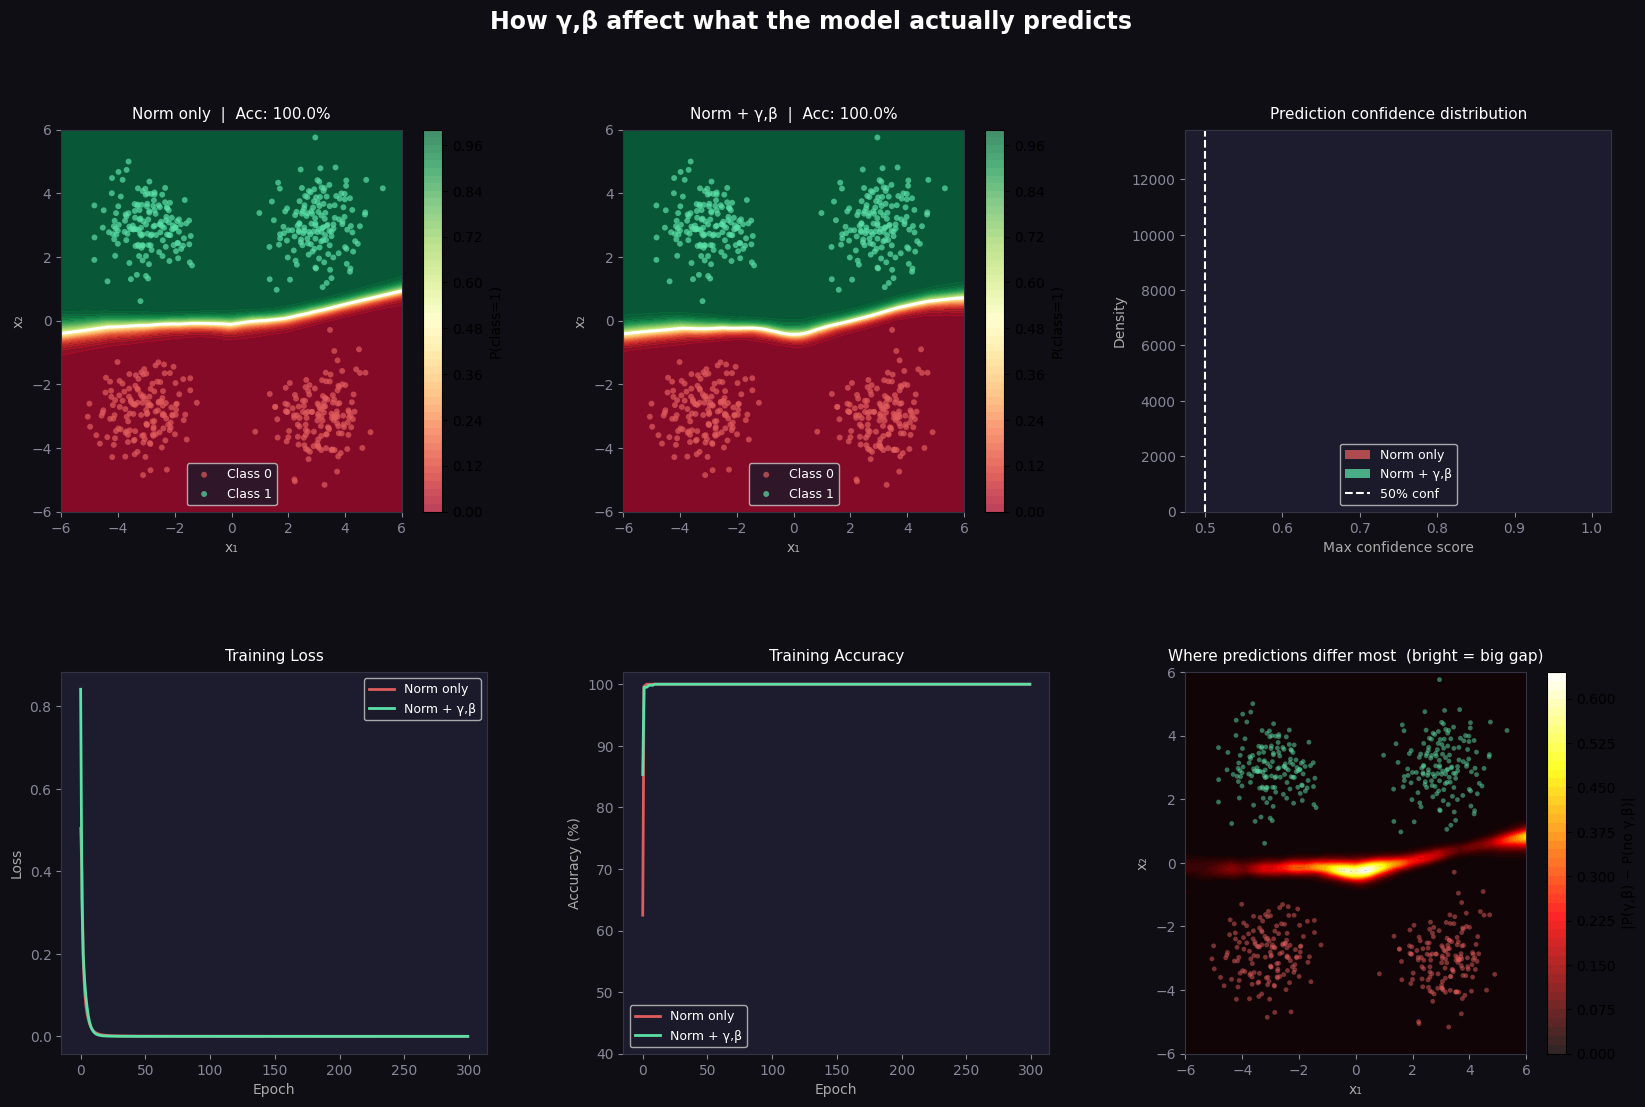

In [ ]:
"""
BatchNorm: How γ,β impact model predictions
============================================
Visualizes decision boundaries side by side:
  Left  → BN without γ,β  (normalize only)
  Right → BN with learned γ,β

Also shows confidence scores across the input space.
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

torch.manual_seed(42)

# ── 1. Dummy data (harder: overlapping clusters + one curved region) ───────────
N = 300

# Class 0: two blobs
X0a = torch.randn(N//2, 2) * 0.8 + torch.tensor([-3.0, -3.0])
X0b = torch.randn(N//2, 2) * 0.8 + torch.tensor([ 3.0, -3.0])

# Class 1: two blobs
X1a = torch.randn(N//2, 2) * 0.8 + torch.tensor([-3.0,  3.0])
X1b = torch.randn(N//2, 2) * 0.8 + torch.tensor([ 3.0,  3.0])

X  = torch.cat([X0a, X0b, X1a, X1b], dim=0)
y  = torch.cat([torch.zeros(N), torch.ones(N)]).long()

perm  = torch.randperm(2 * N)
X, y  = X[perm], y[perm]


# ── 2. Models ──────────────────────────────────────────────────────────────────
class NetNormOnly(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.BatchNorm1d(128, affine=False),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64, affine=False),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32, affine=False),
            nn.ReLU(),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        return self.net(x)


class NetWithAffine(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.BatchNorm1d(128, affine=True),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64, affine=True),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32, affine=True),
            nn.ReLU(),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        return self.net(x)


# ── 3. Train ───────────────────────────────────────────────────────────────────
def train(model, epochs=300, lr=0.02):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses, accs = [], []
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        out  = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X).argmax(1)
            acc   = (preds == y).float().mean().item()
        losses.append(loss.item())
        accs.append(acc * 100)
    return losses, accs


print("Training model WITHOUT γ,β ...")
m_no = NetNormOnly()
loss_no, acc_no = train(m_no)

print("Training model WITH    γ,β ...")
m_af = NetWithAffine()
loss_af, acc_af = train(m_af)


# ── 4. Decision boundary helper ────────────────────────────────────────────────
def get_boundary(model, x_range=(-6, 6), y_range=(-6, 6), steps=300):
    """Returns meshgrid + probability of class 1 across the 2D space."""
    xx, yy = np.meshgrid(
        np.linspace(*x_range, steps),
        np.linspace(*y_range, steps)
    )
    grid = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32
    )
    model.eval()
    with torch.no_grad():
        logits = model(grid)
        probs  = torch.softmax(logits, dim=1)[:, 1].numpy()
    return xx, yy, probs.reshape(xx.shape)


print("Computing decision boundaries ...")
xx, yy, Z_no = get_boundary(m_no)
_,  _,  Z_af = get_boundary(m_af)

X_np = X.numpy()
y_np = y.numpy()


# ── 5. Confidence histogram ────────────────────────────────────────────────────
def get_confidence(model):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs  = torch.softmax(logits, dim=1)
        conf   = probs.max(dim=1).values.numpy()
    return conf

conf_no = get_confidence(m_no)
conf_af = get_confidence(m_af)


# ── 6. Plot ────────────────────────────────────────────────────────────────────
BG   = '#0e0e14'
AX   = '#1c1c2e'
C0   = '#e05c5c'   # class 0 — red
C1   = '#5ce0a8'   # class 1 — green
C_NO = '#e05c5c'
C_AF = '#5ce0a8'

fig = plt.figure(figsize=(20, 12), facecolor=BG)
fig.suptitle(
    'How γ,β affect what the model actually predicts',
    fontsize=17, color='white', fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.32)

def style(ax, title):
    ax.set_facecolor(AX)
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.tick_params(colors='#888899')
    for sp in ax.spines.values():
        sp.set_edgecolor('#333344')
    ax.xaxis.label.set_color('#aaaaaa')
    ax.yaxis.label.set_color('#aaaaaa')


# ── Decision boundary: Norm only ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cf1 = ax1.contourf(xx, yy, Z_no, levels=50, cmap='RdYlGn', alpha=0.75, vmin=0, vmax=1)
ax1.contour(xx, yy, Z_no, levels=[0.5], colors='white', linewidths=2)
ax1.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c=C0, s=18, alpha=0.7, edgecolors='none', label='Class 0')
ax1.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c=C1, s=18, alpha=0.7, edgecolors='none', label='Class 1')
ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')
ax1.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
fig.colorbar(cf1, ax=ax1, label='P(class=1)')
style(ax1, f'Norm only  |  Acc: {acc_no[-1]:.1f}%')

# ── Decision boundary: With γ,β ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cf2 = ax2.contourf(xx, yy, Z_af, levels=50, cmap='RdYlGn', alpha=0.75, vmin=0, vmax=1)
ax2.contour(xx, yy, Z_af, levels=[0.5], colors='white', linewidths=2)
ax2.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c=C0, s=18, alpha=0.7, edgecolors='none', label='Class 0')
ax2.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c=C1, s=18, alpha=0.7, edgecolors='none', label='Class 1')
ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
ax2.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
fig.colorbar(cf2, ax=ax2, label='P(class=1)')
style(ax2, f'Norm + γ,β  |  Acc: {acc_af[-1]:.1f}%')

# ── Confidence histogram ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(conf_no, bins=30, color=C_NO, alpha=0.75, label='Norm only', density=True)
ax3.hist(conf_af, bins=30, color=C_AF, alpha=0.75, label='Norm + γ,β', density=True)
ax3.axvline(0.5, color='white', lw=1.5, linestyle='--', label='50% conf')
ax3.set_xlabel('Max confidence score'); ax3.set_ylabel('Density')
ax3.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax3, 'Prediction confidence distribution')

# ── Loss curves ────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(loss_no, color=C_NO, lw=2, label='Norm only')
ax4.plot(loss_af, color=C_AF, lw=2, label='Norm + γ,β')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
ax4.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax4, 'Training Loss')

# ── Accuracy curves ────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(acc_no, color=C_NO, lw=2, label='Norm only')
ax5.plot(acc_af, color=C_AF, lw=2, label='Norm + γ,β')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Accuracy (%)')
ax5.set_ylim([40, 102])
ax5.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax5, 'Training Accuracy')

# ── Uncertainty map: difference between the two models ────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
diff = np.abs(Z_af - Z_no)
cf6  = ax6.contourf(xx, yy, diff, levels=50, cmap='hot', alpha=0.85)
ax6.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c=C0, s=12, alpha=0.5, edgecolors='none')
ax6.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c=C1, s=12, alpha=0.5, edgecolors='none')
ax6.set_xlabel('x₁'); ax6.set_ylabel('x₂')
fig.colorbar(cf6, ax=ax6, label='|P(γ,β) − P(no γ,β)|')
style(ax6, 'Where predictions differ most  (bright = big gap)')

# ── Print summary ──────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Final accuracy  | Norm only : {acc_no[-1]:.1f}%")
print(f"                  | With γ,β  : {acc_af[-1]:.1f}%")
print(f"  Mean confidence | Norm only : {conf_no.mean()*100:.1f}%")
print(f"                  | With γ,β  : {conf_af.mean()*100:.1f}%")
print(f"  High conf (>90%)| Norm only : {(conf_no > 0.9).mean()*100:.1f}% of samples")
print(f"                  | With γ,β  : {(conf_af > 0.9).mean()*100:.1f}% of samples")
print(f"{'='*55}")
print("  → Brighter regions in the last plot = where γ,β")
print("    caused the model to predict differently.")

# plt.savefig('/mnt/user-data/outputs/batchnorm_decision_boundary.png',
#             dpi=150, bbox_inches='tight', facecolor=BG)
print("\nPlot saved → batchnorm_decision_boundary.png")
plt.show()

Training WITHOUT γ,β  (8-layer + Tanh) ...
Training WITH    γ,β  (8-layer + Tanh) ...
Computing boundaries ...

  Final accuracy  | Norm only : 53.8%
                  | With γ,β  : 63.0%
  Saturation L1   | Norm only : 0.576  |  γ,β: 0.589
  Saturation L7   | Norm only : 0.667  |  γ,β: 0.672
  → Higher saturation in deeper layers = activations stuck
    near ±1, gradients vanish, network stops learning.
  → γ,β rescales inputs to Tanh so it stays in active zone.

Plot saved → batchnorm_spiral.png


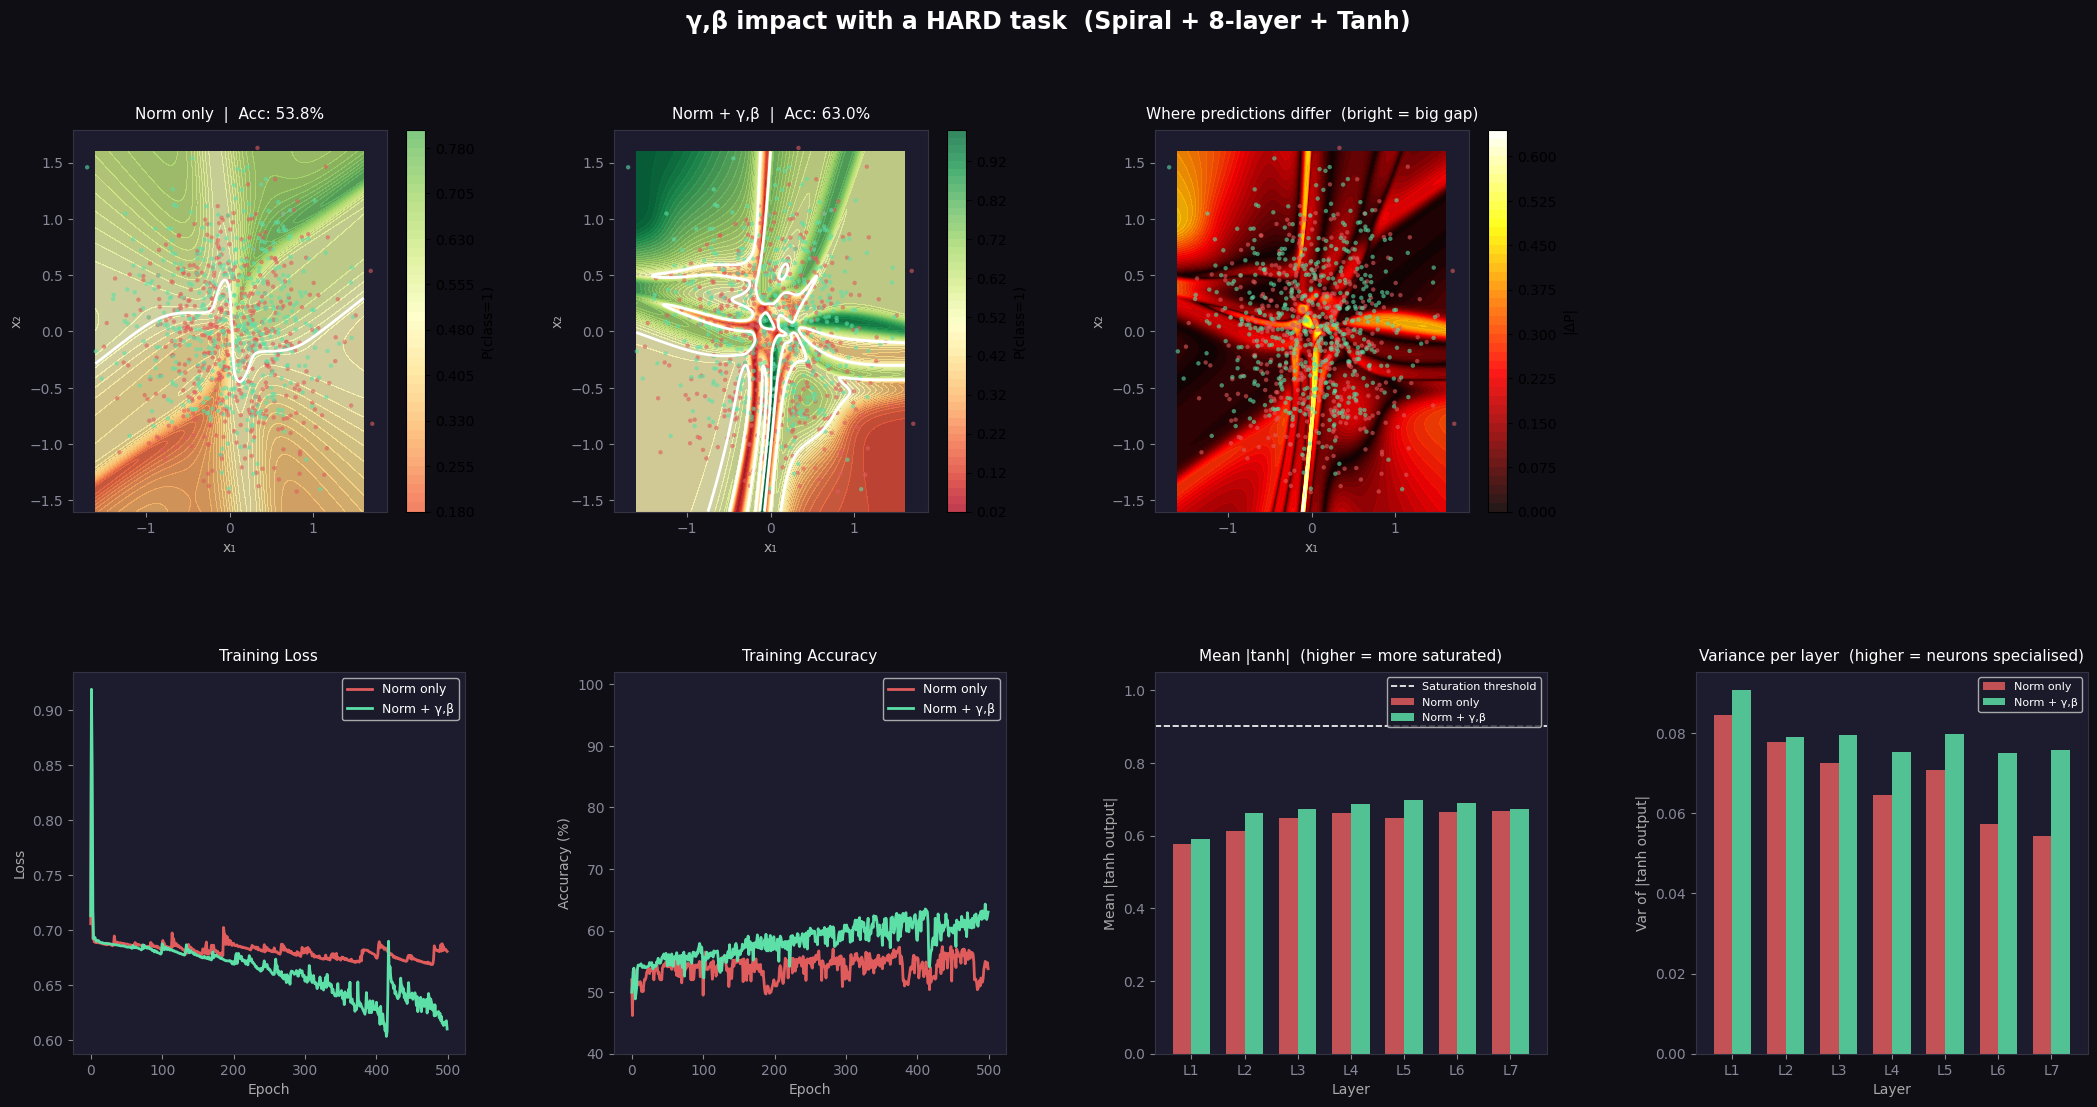

In [12]:
"""
BatchNorm γ,β impact — harder setting where the difference is VISIBLE
======================================================================
Key changes from v1:
  - Spiral dataset  (non-linear, requires expressive activations)
  - Deeper network  (8 layers — normalization collapse matters more)
  - Tanh activation (saturates; γ,β needed to stay in nonlinear regime)
"""

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

torch.manual_seed(0)

# ── 1. Spiral dataset (genuinely non-linear) ───────────────────────────────────
def make_spiral(n=500, noise=0.4):
    t  = torch.linspace(0, 4 * np.pi, n)
    r  = t / (4 * np.pi)
    X0 = torch.stack([r * torch.cos(t) + noise * torch.randn(n),
                      r * torch.sin(t) + noise * torch.randn(n)], dim=1)
    X1 = torch.stack([r * torch.cos(t + np.pi) + noise * torch.randn(n),
                      r * torch.sin(t + np.pi) + noise * torch.randn(n)], dim=1)
    X  = torch.cat([X0, X1], dim=0)
    y  = torch.cat([torch.zeros(n), torch.ones(n)]).long()
    perm = torch.randperm(2 * n)
    return X[perm], y[perm]

X, y = make_spiral()


# ── 2. Deep networks with Tanh (saturation-prone) ─────────────────────────────
def make_block(in_f, out_f, affine):
    return nn.Sequential(
        nn.Linear(in_f, out_f),
        nn.BatchNorm1d(out_f, affine=affine),
        nn.Tanh(),                          # ← saturates; γ,β critical here
    )

class DeepNet(nn.Module):
    def __init__(self, affine):
        super().__init__()
        self.layers = nn.Sequential(
            make_block(2,  64, affine),
            make_block(64, 64, affine),
            make_block(64, 64, affine),
            make_block(64, 64, affine),
            make_block(64, 64, affine),
            make_block(64, 64, affine),
            make_block(64, 32, affine),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        return self.layers(x)


# ── 3. Train ───────────────────────────────────────────────────────────────────
def train(model, epochs=500, lr=0.01):
    opt  = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    losses, accs = [], []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        loss = crit(model(X), y)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            acc = (model(X).argmax(1) == y).float().mean().item()
        losses.append(loss.item())
        accs.append(acc * 100)
    return losses, accs

print("Training WITHOUT γ,β  (8-layer + Tanh) ...")
m_no = DeepNet(affine=False)
loss_no, acc_no = train(m_no)

print("Training WITH    γ,β  (8-layer + Tanh) ...")
m_af = DeepNet(affine=True)
loss_af, acc_af = train(m_af)


# ── 4. Decision boundary ──────────────────────────────────────────────────────
def boundary(model, steps=400):
    lim = 1.6
    xx, yy = np.meshgrid(np.linspace(-lim, lim, steps),
                         np.linspace(-lim, lim, steps))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        Z = torch.softmax(model(grid), 1)[:, 1].numpy()
    return xx, yy, Z.reshape(xx.shape)

print("Computing boundaries ...")
xx, yy, Z_no = boundary(m_no)
_,  _,  Z_af = boundary(m_af)

X_np = X.numpy();  y_np = y.numpy()


# ── 5. Activation saturation per layer ────────────────────────────────────────
# Measure mean |tanh output| per layer — values near 1.0 = saturated
def activation_stats_per_layer(model):
    means, variances = [], []
    handles = []

    for mod in model.layers:
        if isinstance(mod, nn.Sequential):
            tanh_layer = mod[-1]
            def make_hook():
                def hook(m, inp, out):
                    a = out.detach().abs()
                    means.append(a.mean().item())
                    variances.append(a.var().item())
                return hook
            handles.append(tanh_layer.register_forward_hook(make_hook()))

    model.eval()
    with torch.no_grad():
        model(X[:256])
    for h in handles:
        h.remove()
    return means, variances

sat_no, var_no = activation_stats_per_layer(m_no)
sat_af, var_af = activation_stats_per_layer(m_af)
layer_labels = [f'L{i+1}' for i in range(len(sat_no))]


# ── 6. Plot ────────────────────────────────────────────────────────────────────
BG = '#0e0e14';  AX = '#1c1c2e'
C0 = '#e05c5c';  C1 = '#5ce0a8'

fig = plt.figure(figsize=(26, 12), facecolor=BG)
fig.suptitle(
    'γ,β impact with a HARD task  (Spiral + 8-layer + Tanh)',
    fontsize=17, color='white', fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.42, wspace=0.38)

def style(ax, title):
    ax.set_facecolor(AX)
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.tick_params(colors='#888899')
    for sp in ax.spines.values(): sp.set_edgecolor('#333344')
    ax.xaxis.label.set_color('#aaaaaa')
    ax.yaxis.label.set_color('#aaaaaa')

def scatter(ax):
    ax.scatter(X_np[y_np==0,0], X_np[y_np==0,1], c=C0, s=10, alpha=0.6, edgecolors='none')
    ax.scatter(X_np[y_np==1,0], X_np[y_np==1,1], c=C1, s=10, alpha=0.6, edgecolors='none')

# decision boundary — no affine
ax1 = fig.add_subplot(gs[0, 0])
cf1 = ax1.contourf(xx, yy, Z_no, levels=50, cmap='RdYlGn', alpha=0.8, vmin=0, vmax=1)
ax1.contour(xx, yy, Z_no, levels=[0.5], colors='white', linewidths=2)
scatter(ax1)
fig.colorbar(cf1, ax=ax1, label='P(class=1)')
ax1.set_xlabel('x₁'); ax1.set_ylabel('x₂')
style(ax1, f'Norm only  |  Acc: {acc_no[-1]:.1f}%')

# decision boundary — with affine
ax2 = fig.add_subplot(gs[0, 1])
cf2 = ax2.contourf(xx, yy, Z_af, levels=50, cmap='RdYlGn', alpha=0.8, vmin=0, vmax=1)
ax2.contour(xx, yy, Z_af, levels=[0.5], colors='white', linewidths=2)
scatter(ax2)
fig.colorbar(cf2, ax=ax2, label='P(class=1)')
ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
style(ax2, f'Norm + γ,β  |  Acc: {acc_af[-1]:.1f}%')

# prediction difference map
ax3 = fig.add_subplot(gs[0, 2])
diff = np.abs(Z_af - Z_no)
cf3  = ax3.contourf(xx, yy, diff, levels=50, cmap='hot', alpha=0.9)
scatter(ax3)
fig.colorbar(cf3, ax=ax3, label='|ΔP|')
ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')
style(ax3, 'Where predictions differ  (bright = big gap)')

# loss
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(loss_no, color=C0, lw=2, label='Norm only')
ax4.plot(loss_af, color=C1, lw=2, label='Norm + γ,β')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Loss')
ax4.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax4, 'Training Loss')

# accuracy
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(acc_no, color=C0, lw=2, label='Norm only')
ax5.plot(acc_af, color=C1, lw=2, label='Norm + γ,β')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Accuracy (%)')
ax5.set_ylim([40, 102])
ax5.legend(fontsize=9, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax5, 'Training Accuracy')

# saturation per layer
ax6 = fig.add_subplot(gs[1, 2])
x_pos = np.arange(len(layer_labels))
w = 0.35
ax6.bar(x_pos - w/2, sat_no, w, color=C0, alpha=0.85, label='Norm only')
ax6.bar(x_pos + w/2, sat_af, w, color=C1, alpha=0.85, label='Norm + γ,β')
ax6.axhline(0.9, color='white', lw=1.2, linestyle='--', label='Saturation threshold')
ax6.set_xticks(x_pos); ax6.set_xticklabels(layer_labels)
ax6.set_xlabel('Layer'); ax6.set_ylabel('Mean |tanh output|')
ax6.set_ylim([0, 1.05])
ax6.legend(fontsize=8, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax6, 'Mean |tanh|  (higher = more saturated)')

# variance per layer  ← new
ax7 = fig.add_subplot(gs[1, 3])
ax7.bar(x_pos - w/2, var_no, w, color=C0, alpha=0.85, label='Norm only')
ax7.bar(x_pos + w/2, var_af, w, color=C1, alpha=0.85, label='Norm + γ,β')
ax7.set_xticks(x_pos); ax7.set_xticklabels(layer_labels)
ax7.set_xlabel('Layer'); ax7.set_ylabel('Var of |tanh output|')
ax7.legend(fontsize=8, facecolor='#1a1a2a', labelcolor='white', framealpha=0.8)
style(ax7, 'Variance per layer  (higher = neurons specialised)')

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Final accuracy  | Norm only : {acc_no[-1]:.1f}%")
print(f"                  | With γ,β  : {acc_af[-1]:.1f}%")
print(f"  Saturation L1   | Norm only : {sat_no[0]:.3f}  |  γ,β: {sat_af[0]:.3f}")
print(f"  Saturation L7   | Norm only : {sat_no[-1]:.3f}  |  γ,β: {sat_af[-1]:.3f}")
print(f"{'='*55}")
print("  → Higher saturation in deeper layers = activations stuck")
print("    near ±1, gradients vanish, network stops learning.")
print("  → γ,β rescales inputs to Tanh so it stays in active zone.")

# plt.savefig('/mnt/user-data/outputs/batchnorm_spiral.png',
#             dpi=150, bbox_inches='tight', facecolor=BG)
print("\nPlot saved → batchnorm_spiral.png")
plt.show()